# Inflex load forecasting

This notebook builds 15-minute forecasts of **inflex load** for 2025 based on 2024 data.

- `inflex_load_forecast_2025[t]`: 15-min inflex load forecast (kWh per interval).

It evaluates forecasting strategies on 2025 data:

- **Strategy A**: Same time last week (benchmark).
- **Strategy B**: Average of last K weeks (same time).

## Part 1 – Data input and preparation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_DIR = Path("../data")
TRAIN_PATH_2024 = DATA_DIR / "plant1_2024_training.csv"
DATA_2025_PATH = DATA_DIR / "plant1.csv"

TRAIN_PATH_2024, DATA_2025_PATH

(WindowsPath('../data/plant1_2024_training.csv'),
 WindowsPath('../data/plant1.csv'))

In [2]:
# Load 2024 training data (inflex_load) and 2025 full data


def load_inflex_data():
    """Load 2024 inflex load training data and 2025 full data with consistent timestamp parsing.

    - Parse timestamps as UTC, convert to Europe/Brussels, drop tzinfo (naive local).
    """
    df_2024 = pd.read_csv(TRAIN_PATH_2024)
    df_2025 = pd.read_csv(DATA_2025_PATH)

    for df in (df_2024, df_2025):
        ts_utc = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
        df["timestamp"] = ts_utc.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
        df.sort_values("timestamp", inplace=True)

    df_2024["inflex_load"] = pd.to_numeric(df_2024["inflex_load"], errors="coerce").fillna(0.0)
    if "inflex_load" in df_2025.columns:
        df_2025["inflex_load"] = pd.to_numeric(df_2025["inflex_load"], errors="coerce").fillna(0.0)

    df_2024 = df_2024[["timestamp", "inflex_load"]].copy()

    return df_2024.reset_index(drop=True), df_2025.reset_index(drop=True)


df_2024, df_2025 = load_inflex_data()
df_2024.head(), df_2025.head()

(            timestamp  inflex_load
 0 2024-01-01 00:00:00      124.250
 1 2024-01-01 00:15:00      130.375
 2 2024-01-01 00:30:00      142.625
 3 2024-01-01 00:45:00      140.875
 4 2024-01-01 01:00:00      136.500,
             timestamp  grid_consumption  price  pv_production  grid_injection  \
 0 2025-01-01 00:00:00           160.125  10.62            0.0             0.0   
 1 2025-01-01 00:15:00           161.875  10.62            0.0             0.0   
 2 2025-01-01 00:30:00           163.625  10.62            0.0             0.0   
 3 2025-01-01 00:45:00           154.000  10.62            0.0             0.0   
 4 2025-01-01 01:00:00           154.000  10.27            0.0             0.0   
 
    total_consumption   ev  inflex_load  grid_consumption_excl_ev  \
 0            160.125  0.0      160.125                   160.125   
 1            161.875  0.0      161.875                   161.875   
 2            163.625  0.0      163.625                   163.625   
 3           

In [3]:
# Add calendar features. Inflex load is available for the full 2024 period.

for df in (df_2024, df_2025):
    df["date"] = df["timestamp"].dt.date
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["time_of_day"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
    df["month"] = df["timestamp"].dt.month
    df["day_of_year"] = df["timestamp"].dt.dayofyear

print(f"2024: {len(df_2024)} rows, from {df_2024['timestamp'].min()} to {df_2024['timestamp'].max()}")
print(f"2025: {len(df_2025)} rows, from {df_2025['timestamp'].min()} to {df_2025['timestamp'].max()}")
df_2024.tail()

2024: 35136 rows, from 2024-01-01 00:00:00 to 2024-12-31 23:45:00
2025: 35040 rows, from 2025-01-01 00:00:00 to 2025-12-31 23:45:00


,timestamp,inflex_load,date,day_of_week,time_of_day,month,day_of_year
35131,2024-12-31 22:45:00,170.625,2024-12-31,1,22.75,12,366
35132,2024-12-31 23:00:00,175.875,2024-12-31,1,23.00,12,366
35133,2024-12-31 23:15:00,175.000,2024-12-31,1,23.25,12,366
35134,2024-12-31 23:30:00,166.250,2024-12-31,1,23.50,12,366
35135,2024-12-31 23:45:00,165.375,2024-12-31,1,23.75,12,366


### Data sanity check: 2-year view and monthly totals

To check for data issues (e.g. high error in the first month), we plot inflex load over 2024 and 2025 combined, and month-by-month total volumes for both years.

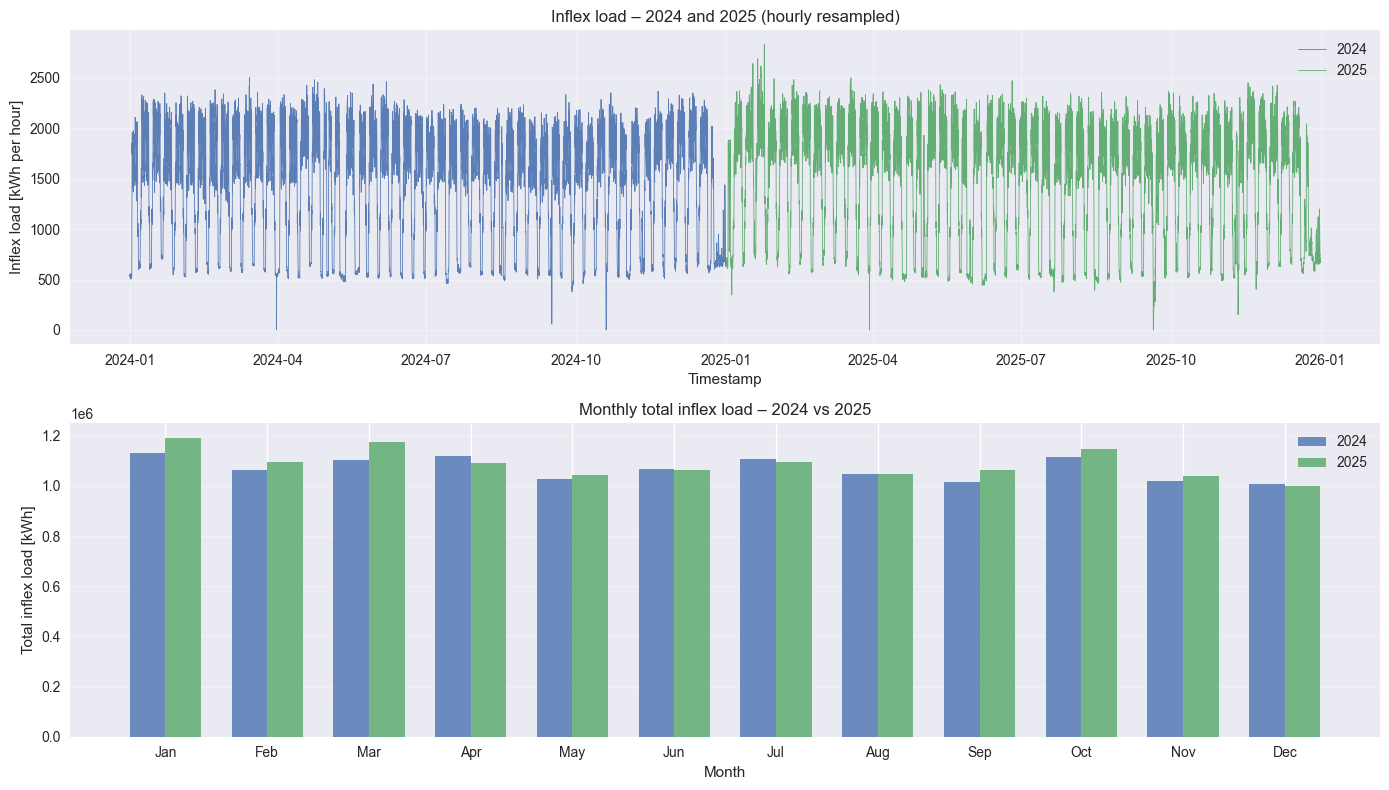

In [4]:
# Combine 2024 and 2025 for 2-year view (resample to hourly for readability)
df_2024_h = df_2024.set_index("timestamp")[["inflex_load"]].resample("1h").sum()
df_2024_h = df_2024_h.reset_index()
df_2024_h["year"] = 2024

df_2025_h = df_2025.set_index("timestamp")[["inflex_load"]].resample("1h").sum()
df_2025_h = df_2025_h.reset_index()
df_2025_h["year"] = 2025

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 1) Two-yearly plot: inflex load 2024 and 2025 combined (hourly)
ax = axes[0]
ax.plot(df_2024_h["timestamp"], df_2024_h["inflex_load"], label="2024", linewidth=0.6, alpha=0.9)
ax.plot(df_2025_h["timestamp"], df_2025_h["inflex_load"], label="2025", linewidth=0.6, alpha=0.9)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Inflex load [kWh per hour]")
ax.set_title("Inflex load – 2024 and 2025 (hourly resampled)")
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Month-by-month total volume: 2024 vs 2025
monthly_2024 = df_2024.groupby(df_2024["timestamp"].dt.to_period("M"))["inflex_load"].sum()
monthly_2025 = df_2025.groupby(df_2025["timestamp"].dt.to_period("M"))["inflex_load"].sum()

# Full month range for alignment
months = np.arange(1, 13)
periods_2024 = [pd.Period(year=2024, month=m, freq="M") for m in months]
periods_2025 = [pd.Period(year=2025, month=m, freq="M") for m in months]
vals_2024 = monthly_2024.reindex(periods_2024).values
vals_2025 = monthly_2025.reindex(periods_2025).values

ax = axes[1]
width = 0.35
ax.bar(months - width / 2, vals_2024, width=width, label="2024", alpha=0.8)
ax.bar(months + width / 2, vals_2025, width=width, label="2025", alpha=0.8)
ax.set_xlabel("Month")
ax.set_ylabel("Total inflex load [kWh]")
ax.set_title("Monthly total inflex load – 2024 vs 2025")
ax.set_xticks(months)
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2 – Forecasting strategies

This section defines and applies forecasting strategies for inflex load:

- **Strategy A**: Same time last week (benchmark).
- **Strategy B**: Average of last K weeks (same time).

**Holiday exclusion (optional):** Set `EXCLUDE_LAST_WEEKS_OF_YEAR = 2` to exclude the last 2 weeks of the year (e.g. Christmas period) from being used as forecast source; set to `0` to disable.

In [5]:
# Exclude last N weeks of the year from forecast source (holiday period). Set to 0 to disable.
EXCLUDE_LAST_WEEKS_OF_YEAR = 2  # e.g. 2 = last 2 weeks (Dec 18–31)

def in_excluded_period(ts):
    """True if timestamp falls in the last EXCLUDE_LAST_WEEKS_OF_YEAR weeks of the year."""
    if EXCLUDE_LAST_WEEKS_OF_YEAR <= 0:
        return np.zeros(len(ts), dtype=bool) if hasattr(ts, "__len__") else False
    t = pd.Series(ts) if not isinstance(ts, pd.Series) else ts
    doy = t.dt.dayofyear.values
    days_in_year = 366 if t.dt.is_leap_year.any() else 365
    threshold = days_in_year - 7 * EXCLUDE_LAST_WEEKS_OF_YEAR + 1
    return doy >= threshold

In [6]:
# Strategy A – Same time last week (benchmark) for 2025
# For the first week of 2025 (no "last week" in 2025), use last weeks of 2024.
# If EXCLUDE_LAST_WEEKS_OF_YEAR > 0, skip lags whose source falls in that period; use next non-excluded lag.
# Use timestamp-based lookup (no merge) so DST duplicate timestamps do not multiply rows.

_df_2025 = df_2025.copy().sort_values("timestamp").reset_index(drop=True)

# One row per naive timestamp (avoids duplicate keys when mapping; keep first occurrence)
inflex_2024_by_ts = df_2024.drop_duplicates(subset=["timestamp"], keep="first").set_index("timestamp")["inflex_load"]
inflex_2025_by_ts = _df_2025.drop_duplicates(subset=["timestamp"], keep="first").set_index("timestamp")["inflex_load"]

LAG_DAYS = [7, 14, 21, 28, 35]
prev_2025_cols = []
prev_2024_cols = []

for L in LAG_DAYS:
    source_ts = _df_2025["timestamp"] - pd.Timedelta(days=L)
    _df_2025[f"prev_2025_L{L}"] = source_ts.map(inflex_2025_by_ts)
    _df_2025[f"prev_2024_L{L}"] = source_ts.map(inflex_2024_by_ts)
    prev_2025_cols.append(f"prev_2025_L{L}")
    prev_2024_cols.append(f"prev_2024_L{L}")

# For each lag L, source timestamp is t - L days; exclude if in holiday period
ts = _df_2025["timestamp"]
forecast = np.full(len(_df_2025), np.nan)
for i, L in enumerate(LAG_DAYS):
    source_ts = ts - pd.Timedelta(days=L)
    excluded = in_excluded_period(source_ts)
    prev_2025 = _df_2025[prev_2025_cols[i]]
    prev_2024 = _df_2025[prev_2024_cols[i]]
    val = prev_2025.fillna(prev_2024)
    use = ~excluded & val.notna()
    forecast[use] = np.where(np.isnan(forecast[use]), val[use].values, forecast[use])

_df_2025["inflex_load_forecast_2025"] = np.where(np.isnan(forecast), 0.0, forecast)
# Drop temporary lag columns to keep dataframe clean
_df_2025 = _df_2025.drop(columns=[c for c in _df_2025.columns if c.startswith("prev_202") and "L" in c])

df_2025 = _df_2025

inflex_load_forecast_2025 = df_2025.set_index("timestamp")["inflex_load_forecast_2025"]

### Strategy C – Chronos2 (daily quantiles p10/p50/p90)

Strategy C uses **Chronos2** to generate a **daily day-ahead** forecast for inflexible load.

- We issue a forecast each day (batched for speed).
- We predict a **96-step (24 h) horizon** at 15‑minute resolution.
- We store **quantiles** p10/p50/p90 as separate forecast columns.

Unlike EV, **inflex load does not require weekday/time-window masking**.

In [7]:
# Strategy C – Chronos2 daily (96-step) inflex load forecast for 2025 with quantiles p10/p50/p90/p95

import torch
from chronos import Chronos2Pipeline

# --- Parameters ---
CHRONOS2_MODEL_NAME = "amazon/chronos-2"
CHRONOS2_CONTEXT_LENGTH = 14 * 96   # 14 days history
H_DAY = 96                          # 24h horizon
BATCH_DAYS = 16                     # number of forecast origins per Chronos call

_device = "cuda" if torch.cuda.is_available() else "cpu"
chronos2 = Chronos2Pipeline.from_pretrained(
    CHRONOS2_MODEL_NAME,
    torch_dtype=torch.float32,
    device_map=_device,
)

_df_c = df_2025.copy().sort_values("timestamp").reset_index(drop=True)
_df_c["date"] = _df_c["timestamp"].dt.date

n = len(_df_c)
if n != 35040:
    print(f"[WARN] Expected 35040 rows for 2025 (15-min), got n={n}.")

# Build history: 2024 + 2025 actual inflex_load (allowed as past-only context per forecast origin)
df_2024_sorted = df_2024.copy().sort_values("timestamp")
inflex24 = df_2024_sorted["inflex_load"].astype(float).to_numpy(dtype=np.float32)

inflex25 = _df_c["inflex_load"].astype(float).to_numpy(dtype=np.float32)

hist_all = np.concatenate([inflex24, inflex25])
offset_2025 = len(inflex24)

# Output arrays (full 2025 grid)
fc_p10 = np.full(n, np.nan, dtype=float)
fc_p50 = np.full(n, np.nan, dtype=float)
fc_p90 = np.full(n, np.nan, dtype=float)
fc_p95 = np.full(n, np.nan, dtype=float)
fc_p99 = np.full(n, np.nan, dtype=float)

# Determine day start indices (assumes 96 points per day)
num_days = n // 96
if num_days * 96 != n:
    raise ValueError(f"Expected full days (n multiple of 96), got n={n}")

day_starts = [d * 96 for d in range(num_days)]

# Forecast day by day (but batched)
for start in range(0, len(day_starts), BATCH_DAYS):
    batch_starts = day_starts[start : start + BATCH_DAYS]
    d0 = _df_c["timestamp"].iloc[batch_starts[0]].date()
    d1 = _df_c["timestamp"].iloc[batch_starts[-1]].date()
    print(f"[Chronos2] Inflex Strategy C: forecasting days {d0} ... {d1} (n={len(batch_starts)})")

    ctx_list = []
    for k0 in batch_starts:
        end = offset_2025 + k0  # context strictly before k0
        ctx = hist_all[max(0, end - CHRONOS2_CONTEXT_LENGTH) : end]
        if len(ctx) < CHRONOS2_CONTEXT_LENGTH:
            ctx = np.concatenate(
                [np.zeros(CHRONOS2_CONTEXT_LENGTH - len(ctx), dtype=np.float32), ctx]
            )
        else:
            ctx = ctx.astype(np.float32)
        ctx_list.append(ctx)

    ctx_batch = np.stack(ctx_list, axis=0)
    ctx_t = torch.tensor(ctx_batch, dtype=torch.float32).view(len(batch_starts), 1, -1)

    q, _mean = chronos2.predict_quantiles(
        inputs=ctx_t,
        prediction_length=H_DAY,
        quantile_levels=[0.1, 0.5, 0.9, 0.95, 0.99],
        limit_prediction_length=False,
    )

    def _q_to_p10_p50_p90_p95_p99(
        q_one: torch.Tensor,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        arr = q_one.detach().cpu().numpy()
        if arr.ndim == 3 and arr.shape[0] == 1:
            arr = arr[0]
        # Accept (H, 5) or (5, H)
        if arr.shape == (H_DAY, 5):
            p10, p50, p90, p95, p99 = arr[:, 0], arr[:, 1], arr[:, 2], arr[:, 3], arr[:, 4]
        elif arr.shape == (5, H_DAY):
            p10, p50, p90, p95, p99 = arr[0, :], arr[1, :], arr[2, :], arr[3, :], arr[4, :]
        else:
            raise ValueError(f"Unexpected quantile shape per-series: {q_one.shape} -> {arr.shape}")
        return (
            np.clip(p10.astype(float), 0.0, None),
            np.clip(p50.astype(float), 0.0, None),
            np.clip(p90.astype(float), 0.0, None),
            np.clip(p95.astype(float), 0.0, None),
            np.clip(p99.astype(float), 0.0, None),
        )

    if isinstance(q, list):
        if len(q) != len(batch_starts):
            raise ValueError(f"Quantile list length {len(q)} != batch size {len(batch_starts)}")
        for i, k0 in enumerate(batch_starts):
            p10, p50, p90, p95, p99 = _q_to_p10_p50_p90_p95_p99(q[i])
            sl = slice(k0, k0 + H_DAY)
            fc_p10[sl] = p10
            fc_p50[sl] = p50
            fc_p90[sl] = p90
            fc_p95[sl] = p95
            fc_p99[sl] = p99
    else:
        q_arr = q.detach().cpu().numpy()
        if q_arr.ndim != 3:
            raise ValueError(f"Unexpected quantile batch shape: {q_arr.shape}")
        # Convert to (B, H, 5)
        if q_arr.shape[1] == H_DAY and q_arr.shape[2] == 5:
            q_b = q_arr
        elif q_arr.shape[1] == 5 and q_arr.shape[2] == H_DAY:
            q_b = np.transpose(q_arr, (0, 2, 1))
        else:
            raise ValueError(f"Unexpected quantile batch shape: {q_arr.shape}")

        for i, k0 in enumerate(batch_starts):
            sl = slice(k0, k0 + H_DAY)
            fc_p10[sl] = np.clip(q_b[i, :, 0].astype(float), 0.0, None)
            fc_p50[sl] = np.clip(q_b[i, :, 1].astype(float), 0.0, None)
            fc_p90[sl] = np.clip(q_b[i, :, 2].astype(float), 0.0, None)
            fc_p95[sl] = np.clip(q_b[i, :, 3].astype(float), 0.0, None)
            fc_p99[sl] = np.clip(q_b[i, :, 4].astype(float), 0.0, None)

_df_c["inflex_load_forecast_2025_C_p10"] = fc_p10
_df_c["inflex_load_forecast_2025_C_p50"] = fc_p50
_df_c["inflex_load_forecast_2025_C_p90"] = fc_p90
_df_c["inflex_load_forecast_2025_C_p95"] = fc_p95
_df_c["inflex_load_forecast_2025_C_p99"] = fc_p99
_df_c["inflex_load_forecast_2025_C"] = fc_p50  # default

df_2025 = _df_c

print(
    f"Chronos2 Strategy C added: df_2025['inflex_load_forecast_2025_C'] "
    f"(model={CHRONOS2_MODEL_NAME}, device={_device}, context={CHRONOS2_CONTEXT_LENGTH})"
)

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


[Chronos2] Inflex Strategy C: forecasting days 2025-01-01 ... 2025-01-16 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-01-17 ... 2025-02-01 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-02-02 ... 2025-02-17 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-02-18 ... 2025-03-05 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-03-06 ... 2025-03-21 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-03-22 ... 2025-04-06 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-04-07 ... 2025-04-22 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-04-23 ... 2025-05-08 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-05-09 ... 2025-05-24 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-05-25 ... 2025-06-09 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-06-10 ... 2025-06-25 (n=16)
[Chronos2] Inflex Strategy C: forecasting days 2025-06-26 ... 2025-07-11 (n=16)
[Chronos2] Inflex Strategy C: forecastin

### Strategy B – Average of last K weeks (same time)

Strategy B generalizes Strategy A by forecasting each 15‑minute interval as the **average of the same timestamp over the last K weeks**:

- For K=2: average of the last 2 weeks at the same day/time.
- For K=3: average of the last 3 weeks at the same day/time.
- ... up to K=16.

We denote these variants as **B2, B3, ..., B16**; **B1** would coincide with Strategy A and is not recomputed.

In [8]:
# Strategy B – average of last K weeks (same time)
# For each lag week j, value at t-7j days is taken from 2025 if available, else from 2024.
# If EXCLUDE_LAST_WEEKS_OF_YEAR > 0, exclude those j for which t-7j falls in that period from the average.

K_VALUES_B = list(range(1, 17))  # 1..16 (K=1 == Strategy A)

_df_base_2025 = df_2025.copy().sort_values("timestamp").reset_index(drop=True)
ts = _df_base_2025["timestamp"]

# Combined series: 2024 and 2025 inflex_load by timestamp (for looking up t-7j days)
_combined_inflex = pd.concat([
    df_2024.set_index("timestamp")["inflex_load"],
    df_2025.set_index("timestamp")["inflex_load"],
])

for k in K_VALUES_B:
    prev_arrays = []
    excluded_mask = []  # shape (n_rows, k): True if that lag's source is in excluded period
    for j in range(1, k + 1):
        source_ts = ts - pd.Timedelta(days=7 * j)
        excluded_mask.append(in_excluded_period(source_ts))
        lagged_j = _combined_inflex.copy()
        lagged_j.index = lagged_j.index + pd.Timedelta(days=7 * j)
        lagged_j = lagged_j[~lagged_j.index.duplicated(keep="last")]
        prev_j = _df_base_2025["timestamp"].map(lagged_j).to_numpy()
        prev_arrays.append(prev_j)

    vals = np.stack(prev_arrays, axis=1)  # (n, k)
    excluded = np.stack(excluded_mask, axis=1)  # (n, k)
    # Where excluded, set to nan so they are not included in the mean
    vals_masked = np.where(excluded, np.nan, vals)
    with np.errstate(all="ignore"):
        inflex_forecast_k = np.nanmean(vals_masked, axis=1)
    # If all k lags were excluded for a row, fall back to first non-excluded lag (if any)
    all_excluded = np.all(excluded, axis=1)
    if np.any(all_excluded):
        for j in range(k):
            use = all_excluded & ~excluded[:, j] & ~np.isnan(vals[:, j])
            if np.any(use):
                inflex_forecast_k[use] = vals[use, j]
                all_excluded = all_excluded & ~use
    inflex_forecast_k = np.where(np.isnan(inflex_forecast_k), 0.0, inflex_forecast_k)

    _df_base_2025[f"inflex_load_forecast_2025_B{k}"] = inflex_forecast_k

df_2025 = _df_base_2025

C:\Users\VanAmmeT\AppData\Local\Temp\ipykernel_21056\557100729.py:33: RuntimeWarning: Mean of empty slice
  inflex_forecast_k = np.nanmean(vals_masked, axis=1)
C:\Users\VanAmmeT\AppData\Local\Temp\ipykernel_21056\557100729.py:33: RuntimeWarning: Mean of empty slice
  inflex_forecast_k = np.nanmean(vals_masked, axis=1)


## Part 3 – Forecast evaluation and visualization

In this section we compare forecasted inflex load profiles against actual inflex load:

- Compute error metrics for Strategy A on 2025 (15-minute level only).
- Plot representative daily, weekly, monthly, and yearly summaries for visual inspection.

In [9]:
# Error metrics for Strategy C on 2025 (15-min + daily)

required = [
    "inflex_load",
    "inflex_load_forecast_2025_C",
    "date",
]
for c in required:
    if c not in df_2025.columns:
        raise ValueError(f"Missing df_2025[{c!r}]. Run Strategy C cell first.")

_df_eval_C = df_2025.copy().sort_values("timestamp")

# 15-min metrics
err_15 = _df_eval_C["inflex_load_forecast_2025_C"] - _df_eval_C["inflex_load"]
mae_15 = float(err_15.abs().mean())
rmse_15 = float(np.sqrt((err_15 ** 2).mean()))

# Daily totals metrics
_daily_act = _df_eval_C.groupby("date")["inflex_load"].sum()
_daily_fc = _df_eval_C.groupby("date")["inflex_load_forecast_2025_C"].sum()
err_day = _daily_fc - _daily_act
mae_day = float(err_day.abs().mean())
rmse_day = float(np.sqrt((err_day ** 2).mean()))

print("Strategy C (Chronos2) – 2025 inflex load forecast")
print("15-min level (kWh per 15-min):")
print(f"  MAE  = {mae_15:8.3f} kWh")
print(f"  RMSE = {rmse_15:8.3f} kWh")
print()
print("Daily energy level (kWh per day):")
print(f"  MAE  = {mae_day:8.3f} kWh")
print(f"  RMSE = {rmse_day:8.3f} kWh")


Strategy C (Chronos2) – 2025 inflex load forecast
15-min level (kWh per 15-min):
  MAE  =   34.372 kWh
  RMSE =   53.647 kWh

Daily energy level (kWh per day):
  MAE  = 1799.715 kWh
  RMSE = 3143.199 kWh


### 3.1 Error metrics for Strategy A

We evaluate **Strategy A (same time last week)** on 2025 by computing error metrics at the 15‑minute level.

In [10]:
# Error metrics for Strategy A on 2025 (15-min only)

assert "inflex_load" in df_2025.columns, "df_2025 must contain the actual column 'inflex_load'"
assert "inflex_load_forecast_2025" in df_2025.columns, "Run Strategy A cell first to create 'inflex_load_forecast_2025'"

_df_eval = df_2025.copy().sort_values("timestamp")
_df_eval["error_15min"] = _df_eval["inflex_load_forecast_2025"] - _df_eval["inflex_load"]

mae_15min = _df_eval["error_15min"].abs().mean()
rmse_15min = np.sqrt((_df_eval["error_15min"] ** 2).mean())

print("Strategy A – 2025 inflex load forecast")
print("15-min level (kWh per 15-min):")
print(f"  MAE  = {mae_15min:8.3f} kWh")
print(f"  RMSE = {rmse_15min:8.3f} kWh")

Strategy A – 2025 inflex load forecast
15-min level (kWh per 15-min):
  MAE  =   58.914 kWh
  RMSE =   99.089 kWh


### 3.2 Strategy B – Choosing K

To select an appropriate **K** for Strategy B, we compare forecast accuracy across K=1..16 using 15‑minute error metrics (MAE, RMSE) and visualize how these metrics change with K.

Strategy B – forecast accuracy vs K (15-min level) (+A, +C)


,MAE_15min,RMSE_15min
K,,
1,62.729534,106.601976
2,58.926847,99.537045
3,53.555231,87.384359
4,50.428561,82.104333
5,49.118351,80.864328
6,47.478230,78.839786
7,46.273860,76.674188
8,45.888729,76.404017
9,45.742092,76.335339


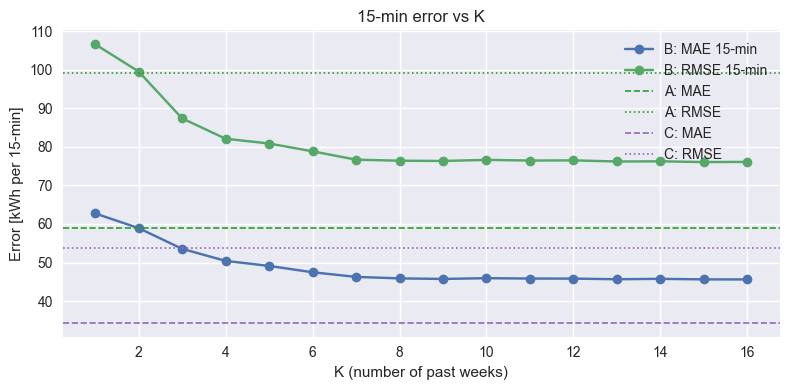

In [11]:
# Error metrics vs K for Strategy B (B1..B16) – 15-min only

K_VALUES_B = list(range(1, 17))
_df_eval_B = df_2025.copy().sort_values("timestamp")

rows = []
for k in K_VALUES_B:
    col = f"inflex_load_forecast_2025_B{k}"
    assert col in _df_eval_B.columns, f"Missing forecast column {col}; run Strategy B cell first."
    err_15 = _df_eval_B[col] - _df_eval_B["inflex_load"]
    mae_15 = err_15.abs().mean()
    rmse_15 = np.sqrt((err_15 ** 2).mean())
    rows.append({"K": k, "MAE_15min": mae_15, "RMSE_15min": rmse_15})

metrics_B = pd.DataFrame(rows).set_index("K")

# Add Strategy A and Strategy C (if available)
def _mae_rmse_for_col(col: str):
    if col not in _df_eval_B.columns:
        return None
    err = _df_eval_B[col] - _df_eval_B["inflex_load"]
    return {
        "MAE_15min": float(err.abs().mean()),
        "RMSE_15min": float(np.sqrt((err ** 2).mean())),
    }

m_A = _mae_rmse_for_col("inflex_load_forecast_2025")
m_C = _mae_rmse_for_col("inflex_load_forecast_2025_C")

metrics_compare = metrics_B.copy()
if m_A is not None:
    metrics_compare.loc["A"] = m_A
if m_C is not None:
    metrics_compare.loc["C"] = m_C

print("Strategy B – forecast accuracy vs K (15-min level) (+A, +C)")
display(metrics_compare)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_B.index, metrics_B["MAE_15min"], marker="o", label="B: MAE 15-min")
ax.plot(metrics_B.index, metrics_B["RMSE_15min"], marker="o", label="B: RMSE 15-min")
if m_A is not None:
    ax.axhline(m_A["MAE_15min"], color="tab:green", linestyle="--", linewidth=1.2, label="A: MAE")
    ax.axhline(m_A["RMSE_15min"], color="tab:green", linestyle=":", linewidth=1.2, label="A: RMSE")
if m_C is not None:
    ax.axhline(m_C["MAE_15min"], color="tab:purple", linestyle="--", linewidth=1.2, label="C: MAE")
    ax.axhline(m_C["RMSE_15min"], color="tab:purple", linestyle=":", linewidth=1.2, label="C: RMSE")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kWh per 15-min]")
ax.set_title("15-min error vs K")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Visual comparison: actual vs forecast

We now compare **actual vs selected strategy forecast** at different horizons (choose strategy in the code cell below, e.g. `"A"` or `"B5"`): a representative day (15‑minute profiles), a representative week, monthly aggregates, and full year (for visualisation only; 15-min forecast is the only output).

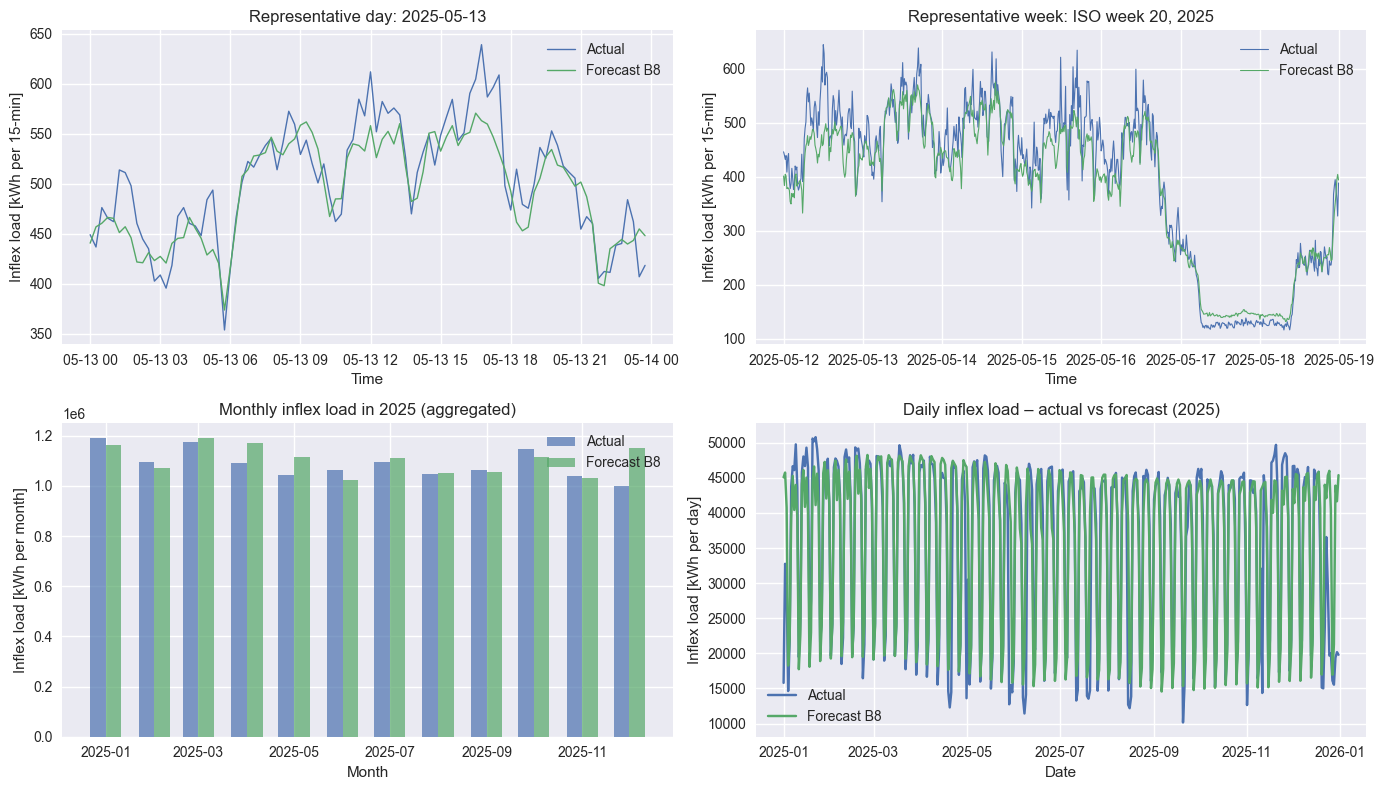

In [12]:
# Visual comparison plots for selected strategy (actual vs forecast inflex load)
# --- Select strategy to visualise: "A" or "B2", "B5", etc. ---
strategy_label = "B8"

_df_plot = df_2025.copy().sort_values("timestamp")
_df_plot["date"] = _df_plot["timestamp"].dt.date
iso = _df_plot["timestamp"].dt.isocalendar()

# Choose forecast column based on strategy label
if strategy_label == "A":
    forecast_col = "inflex_load_forecast_2025"
elif strategy_label == "C":
    forecast_col = "inflex_load_forecast_2025_C"
else:
    if not strategy_label.startswith("B"):
        raise ValueError("strategy_label must be 'A', 'C', or like 'B5', 'B3', ...")
    k_val = int(strategy_label[1:])
    forecast_col = f"inflex_load_forecast_2025_B{k_val}"
if forecast_col not in _df_plot.columns:
    raise ValueError(
        f"Forecast column '{forecast_col}' not found. Run Strategy A/B/C cells first."
    )

# Representative day: e.g. first day of week 20, 2025
rep_week_year_param = 2025
rep_week_param = 20
rep_day_of_week_param = 2  # 1=Mon .. 7=Sun
mask_target = (
    (iso["year"] == rep_week_year_param)
    & (iso["week"] == rep_week_param)
    & (iso["day"] == rep_day_of_week_param)
)
rep_day = _df_plot.loc[mask_target, "date"].iloc[0] if mask_target.any() else _df_plot["date"].iloc[0]
mask_day = _df_plot["date"] == rep_day
_day = _df_plot.loc[mask_day]

rep_year = int(rep_week_year_param)
rep_week = int(rep_week_param)
mask_week = (iso["year"] == rep_year) & (iso["week"] == rep_week)
_week = _df_plot.loc[mask_week]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Daily 15-min profile
ax = axes[0, 0]
ax.plot(_day["timestamp"], _day["inflex_load"], label="Actual", linewidth=1.0)
ax.plot(_day["timestamp"], _day[forecast_col], label=f"Forecast {strategy_label}", linewidth=1.0)
ax.set_title(f"Representative day: {rep_day}")
ax.set_xlabel("Time")
ax.set_ylabel("Inflex load [kWh per 15-min]")
ax.legend()
ax.grid(True)

# 2) Weekly 15-min profile
ax = axes[0, 1]
ax.plot(_week["timestamp"], _week["inflex_load"], label="Actual", linewidth=0.8)
ax.plot(_week["timestamp"], _week[forecast_col], label=f"Forecast {strategy_label}", linewidth=0.8)
ax.set_title(f"Representative week: ISO week {rep_week}, {rep_year}")
ax.set_xlabel("Time")
ax.set_ylabel("Inflex load [kWh per 15-min]")
ax.legend()
ax.grid(True)

# 3) Monthly totals (kWh) – aggregated from 15-min for visualisation
_monthly_actual = _df_plot.groupby(_df_plot["timestamp"].dt.to_period("M"))["inflex_load"].sum()
_monthly_forecast = _df_plot.groupby(_df_plot["timestamp"].dt.to_period("M"))[forecast_col].sum()
months = _monthly_actual.index.to_timestamp()
ax = axes[1, 0]
width = 10
ax.bar(months - pd.Timedelta(days=width/2), _monthly_actual.values, width=width, label="Actual", alpha=0.7)
ax.bar(months + pd.Timedelta(days=width/2), _monthly_forecast.values, width=width, label=f"Forecast {strategy_label}", alpha=0.7)
ax.set_title("Monthly inflex load in 2025 (aggregated)")
ax.set_xlabel("Month")
ax.set_ylabel("Inflex load [kWh per month]")
ax.legend()
ax.grid(True, axis="y")

# 4) Daily totals over full year (for visualisation)
_daily_actual = _df_plot.groupby("date")["inflex_load"].sum()
_daily_forecast = _df_plot.groupby("date")[forecast_col].sum()
ax = axes[1, 1]
ax.plot(_daily_actual.index, _daily_actual.values, label="Actual")
ax.plot(_daily_forecast.index, _daily_forecast.values, label=f"Forecast {strategy_label}")
ax.set_title("Daily inflex load – actual vs forecast (2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Inflex load [kWh per day]")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

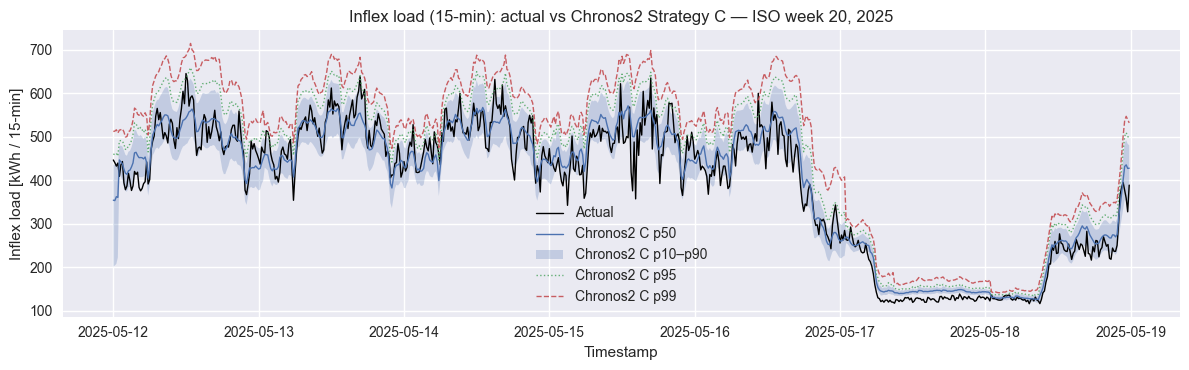

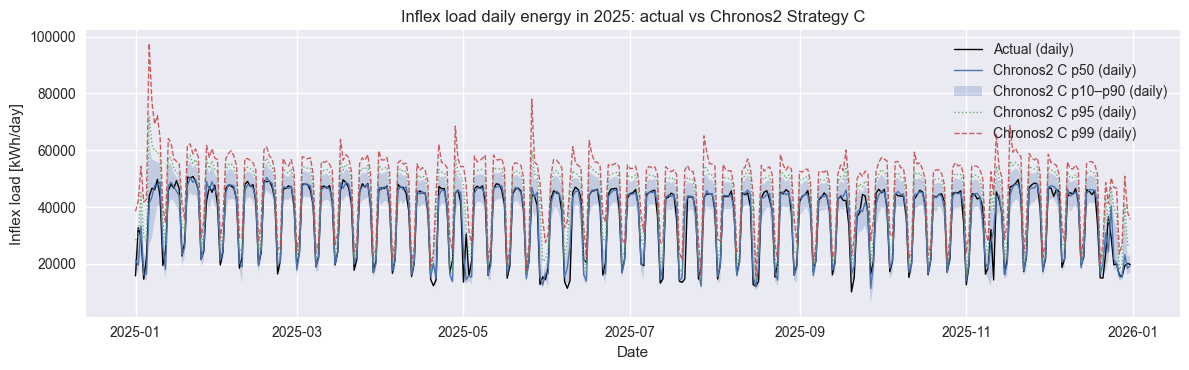

In [13]:
# Visualisation for Strategy C quantiles (p10/p50/p90/p95): ISO week + yearly view

import matplotlib.pyplot as plt

ISO_WEEK_YEAR_C = 2025
ISO_WEEK_C = 20

required_cols = [
    "inflex_load_forecast_2025_C_p10",
    "inflex_load_forecast_2025_C_p50",
    "inflex_load_forecast_2025_C_p90",
    "inflex_load_forecast_2025_C_p95",
    "inflex_load_forecast_2025_C_p99",
]
for c in required_cols:
    if c not in df_2025.columns:
        raise ValueError(f"Missing df_2025[{c!r}]. Run Strategy C cell first.")

_df = df_2025.copy().sort_values("timestamp")
iso = _df["timestamp"].dt.isocalendar()
mask_week = (iso["year"] == ISO_WEEK_YEAR_C) & (iso["week"] == ISO_WEEK_C)
week_df = _df.loc[mask_week]
if week_df.empty:
    raise ValueError(f"No data found for ISO week {ISO_WEEK_C}, {ISO_WEEK_YEAR_C}.")

# ISO-week plot (15-min)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(week_df["timestamp"], week_df["inflex_load"], label="Actual", lw=1.0, color="black")
ax.plot(week_df["timestamp"], week_df["inflex_load_forecast_2025_C_p50"], label="Chronos2 C p50", lw=1.0)
ax.fill_between(
    week_df["timestamp"],
    week_df["inflex_load_forecast_2025_C_p10"],
    week_df["inflex_load_forecast_2025_C_p90"],
    alpha=0.25,
    label="Chronos2 C p10–p90",
)
ax.plot(
    week_df["timestamp"],
    week_df["inflex_load_forecast_2025_C_p95"],
    label="Chronos2 C p95",
    lw=1.0,
    linestyle=":",
    alpha=0.9,
)
ax.plot(
    week_df["timestamp"],
    week_df["inflex_load_forecast_2025_C_p99"],
    label="Chronos2 C p99",
    lw=1.0,
    linestyle="--",
    alpha=0.9,
)
ax.set_title(f"Inflex load (15-min): actual vs Chronos2 Strategy C — ISO week {ISO_WEEK_C}, {ISO_WEEK_YEAR_C}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Inflex load [kWh / 15-min]")
ax.grid(True)
ax.legend()
plt.tight_layout()

# Yearly daily totals
_df["date"] = _df["timestamp"].dt.date

daily_act = _df.groupby("date")["inflex_load"].sum()
daily_p10 = _df.groupby("date")["inflex_load_forecast_2025_C_p10"].sum()
daily_p50 = _df.groupby("date")["inflex_load_forecast_2025_C_p50"].sum()
daily_p90 = _df.groupby("date")["inflex_load_forecast_2025_C_p90"].sum()
daily_p95 = _df.groupby("date")["inflex_load_forecast_2025_C_p95"].sum()
daily_p99 = _df.groupby("date")["inflex_load_forecast_2025_C_p99"].sum()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(daily_act.index, daily_act.values, label="Actual (daily)", lw=1.0, color="black")
ax.plot(daily_p50.index, daily_p50.values, label="Chronos2 C p50 (daily)", lw=1.0)
ax.fill_between(daily_p50.index, daily_p10.values, daily_p90.values, alpha=0.25, label="Chronos2 C p10–p90 (daily)")
ax.plot(daily_p95.index, daily_p95.values, label="Chronos2 C p95 (daily)", lw=1.0, linestyle=":", alpha=0.9)
ax.plot(daily_p99.index, daily_p99.values, label="Chronos2 C p99 (daily)", lw=1.0, linestyle="--", alpha=0.9)
ax.set_title("Inflex load daily energy in 2025: actual vs Chronos2 Strategy C")
ax.set_xlabel("Date")
ax.set_ylabel("Inflex load [kWh/day]")
ax.grid(True)
ax.legend()
plt.tight_layout()

In [14]:
# Export inflex load forecasts to CSV (same format as forecast_ev: timestamps from plant1, one column per strategy)
OUTPUT_DIR = Path("../output")
FORECAST_DIR = OUTPUT_DIR / "forecast"
FORECAST_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_INFLEX_PATH = FORECAST_DIR / "forecast_inflex_load_rolling_horizon.csv"

# Copy timestamps from plant1.csv (same order as df_2025, which is loaded from plant1; includes +01:00/+02:00)
_plant1 = pd.read_csv(DATA_2025_PATH)
export_df = pd.DataFrame({"timestamp": _plant1["timestamp"].values})
export_df["forecast_inflex_a"] = df_2025["inflex_load_forecast_2025"].values
for k in K_VALUES_B:
    export_df[f"forecast_inflex_b{k}"] = df_2025[f"inflex_load_forecast_2025_B{k}"].values

# Chronos2 Strategy C quantiles (use p50 as default for MPC)
if "inflex_load_forecast_2025_C_p50" in df_2025.columns:
    export_df["forecast_inflex_c"] = df_2025["inflex_load_forecast_2025_C_p50"].values
if "inflex_load_forecast_2025_C_p10" in df_2025.columns:
    export_df["forecast_inflex_c_p10"] = df_2025["inflex_load_forecast_2025_C_p10"].values
if "inflex_load_forecast_2025_C_p90" in df_2025.columns:
    export_df["forecast_inflex_c_p90"] = df_2025["inflex_load_forecast_2025_C_p90"].values
if "inflex_load_forecast_2025_C_p95" in df_2025.columns:
    export_df["forecast_inflex_c_p95"] = df_2025["inflex_load_forecast_2025_C_p95"].values
if "inflex_load_forecast_2025_C_p99" in df_2025.columns:
    export_df["forecast_inflex_c_p99"] = df_2025["inflex_load_forecast_2025_C_p99"].values

export_df.to_csv(FORECAST_INFLEX_PATH, index=False)
print(f"Exported {len(export_df)} rows to {FORECAST_INFLEX_PATH}")
export_df.head()

Exported 35040 rows to ..\output\forecast\forecast_inflex_load_rolling_horizon.csv


,timestamp,forecast_inflex_a,forecast_inflex_b1,forecast_inflex_b2,forecast_inflex_b3,forecast_inflex_b4,forecast_inflex_b5,forecast_inflex_b6,forecast_inflex_b7,forecast_inflex_b8,...,forecast_inflex_b12,forecast_inflex_b13,forecast_inflex_b14,forecast_inflex_b15,forecast_inflex_b16,forecast_inflex_c,forecast_inflex_c_p10,forecast_inflex_c_p90,forecast_inflex_c_p95,forecast_inflex_c_p99
0,2025-01-01 00:00:00+01:00,473.375,0.0,0.0,473.375,459.3750,462.875000,455.00000,440.650,443.187500,...,424.1125,426.443182,429.989583,424.778846,419.3125,171.540100,162.883911,180.703705,184.372879,207.735413
1,2025-01-01 00:15:00+01:00,439.250,0.0,0.0,439.250,455.0000,464.625000,462.00000,452.725,445.229167,...,432.2500,432.806818,432.031250,427.605769,424.7500,172.741577,163.917847,183.064362,187.107086,211.563416
2,2025-01-01 00:30:00+01:00,420.000,0.0,0.0,420.000,449.7500,459.666667,458.28125,453.600,448.291667,...,433.9125,435.034091,434.072917,427.875000,423.7500,172.938812,163.735748,183.374054,187.760773,213.016510
3,2025-01-01 00:45:00+01:00,432.250,0.0,0.0,432.250,423.9375,427.291667,427.65625,426.300,426.708333,...,424.9875,422.863636,418.906250,415.894231,412.3750,172.606079,163.429489,183.376068,188.387238,214.129578
4,2025-01-01 01:00:00+01:00,419.125,0.0,0.0,419.125,409.5000,427.000000,426.78125,423.325,422.187500,...,420.0875,422.386364,419.708333,418.519231,411.8125,171.981186,162.851440,183.501709,188.444153,216.210632
